<a href="https://www.kaggle.com/code/avikdas567/global-economic-resilience-growth-intelligence?scriptVersionId=323749557" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Mapping the Global Economy Through 2030

## A Data-Driven Exploration of Growth, Inflation, Debt, Trade, and Economic Resilience

This notebook examines nearly 3,000 country-year observations from the IMF World Economic Outlook April 2026 release. The dataset combines historical macroeconomic performance with IMF projections through 2030, allowing us to study how economies differ in scale, growth dynamics, inflation pressures, external balances, fiscal conditions, and overall resilience.

The analysis progresses from data quality assessment to exploratory analysis, clustering, and machine learning. Rather than focusing on a single country, the objective is to identify broad global patterns and economic archetypes that emerge across nearly two hundred economies.


In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(12,6)

DATA_PATH = "/kaggle/input/datasets/kanchana1990/imf-world-economic-outlook-april-2026/imf_weo_april_2026.csv"


## Data Loading

In [2]:

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()


(2901, 25)


,iso_code,country_name,year,is_forecast,data_vintage,scrape_date,GDP_Nominal_USD_Bn,Real_GDP_Growth_Pct,GDP_Per_Capita_USD,GDP_PPP_USD_Bn,...,Govt_Gross_Debt_Pct_GDP,Govt_Net_Lending_Pct_GDP,Population_Mn,GDP_Growth_Momentum_3Y,Economic_Resilience_Score,Real_Purchasing_Power_Growth,Govt_Revenue_Pct_GDP,Import_Volume_Growth_Pct,Export_Volume_Growth_Pct,is_aggregate_region
0,AFG,Afghanistan,2016,False,IMF WEO April 2026,2026-04-14,18.020,2.2,520.267,79.784,...,8.4,0.1,34.636,2.400,74.70,-2.2,12.6780,NaN,NaN,False
1,AFG,Afghanistan,2017,False,IMF WEO April 2026,2026-04-14,18.883,2.6,529.773,83.362,...,8.0,-0.7,35.643,2.000,75.27,-2.4,13.0393,NaN,NaN,False
2,AFG,Afghanistan,2018,False,IMF WEO April 2026,2026-04-14,18.336,1.2,499.799,89.369,...,7.4,1.6,36.687,2.567,73.28,0.6,NaN,NaN,NaN,False
3,AFG,Afghanistan,2019,False,IMF WEO April 2026,2026-04-14,18.876,3.9,499.762,97.801,...,6.1,-1.1,37.769,0.900,81.91,1.6,NaN,NaN,NaN,False
4,AFG,Afghanistan,2020,False,IMF WEO April 2026,2026-04-14,20.136,-2.4,516.664,100.898,...,7.3,-2.2,38.972,-4.333,61.51,-8.0,NaN,NaN,NaN,False


In [3]:

display(df.info())
display(df.describe(include='all').T.head(30))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2901 entries, 0 to 2900
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   iso_code                      2901 non-null   object 
 1   country_name                  2901 non-null   object 
 2   year                          2901 non-null   int64  
 3   is_forecast                   2901 non-null   bool   
 4   data_vintage                  2901 non-null   object 
 5   scrape_date                   2901 non-null   object 
 6   GDP_Nominal_USD_Bn            2895 non-null   float64
 7   Real_GDP_Growth_Pct           2897 non-null   float64
 8   GDP_Per_Capita_USD            2895 non-null   float64
 9   GDP_PPP_USD_Bn                2900 non-null   float64
 10  GDP_PPP_Per_Capita_USD        2900 non-null   float64
 11  Inflation_CPI_Pct             2891 non-null   float64
 12  Unemployment_Rate_Pct         1628 non-null   float64
 13  Cur

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
iso_code,2901,196,ALB,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_name,2901,196,Albania,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,2901.0,NaN,NaN,NaN,2022.943468,4.312641,2016.0,2019.0,2023.0,2027.0,2030.0
is_forecast,2901,2,False,1953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_vintage,2901,1,IMF WEO April 2026,2901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scrape_date,2901,1,2026-04-14,2901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GDP_Nominal_USD_Bn,2895.0,NaN,NaN,NaN,568.986716,2535.851817,0.041,11.3735,46.844,291.2265,37677.878
Real_GDP_Growth_Pct,2897.0,NaN,NaN,NaN,2.935312,4.723245,-32.9,1.6,3.1,4.8,46.1
GDP_Per_Capita_USD,2895.0,NaN,NaN,NaN,19539.197403,28331.467572,244.862,2682.6605,7574.859,25361.3465,252007.222
GDP_PPP_USD_Bn,2900.0,NaN,NaN,NaN,969.719571,3692.458879,0.041,28.5225,108.854,540.78975,55279.714


## Dataset Audit and Missing Value Analysis

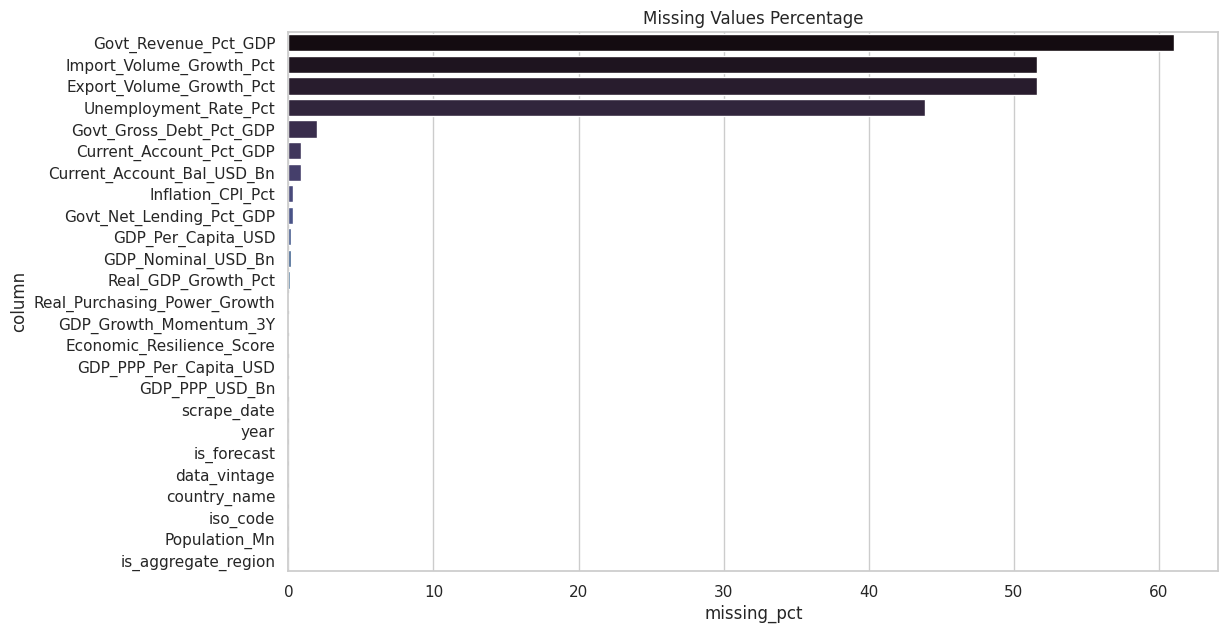

,column,missing_pct
0,Govt_Revenue_Pct_GDP,61.047915
1,Import_Volume_Growth_Pct,51.568425
2,Export_Volume_Growth_Pct,51.568425
3,Unemployment_Rate_Pct,43.881420
4,Govt_Gross_Debt_Pct_GDP,1.999311
5,Current_Account_Pct_GDP,0.896243
6,Current_Account_Bal_USD_Bn,0.861772
7,Inflation_CPI_Pct,0.344709
8,Govt_Net_Lending_Pct_GDP,0.344709
9,GDP_Per_Capita_USD,0.206825


In [4]:

missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ["column","missing_pct"]

plt.figure(figsize=(12,7))
sns.barplot(data=missing, y="column", x="missing_pct", palette="mako")
plt.title("Missing Values Percentage")
plt.show()

missing


### Observations

- The dataset is highly complete for a cross-country macroeconomic panel, with overall coverage above 90%. Missing values are concentrated in a small number of indicators rather than being evenly distributed across the dataset. This level of completeness allows most analyses to proceed without aggressive imputation and increases confidence in cross-country comparisons.

- The presence of a small amount of missingness is expected because some economies do not consistently report fiscal, labor-market, or external-sector indicators across the full time horizon.

## Data Preparation

In [5]:

df = df.copy()

df["year"] = df["year"].astype(int)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    df[col] = df[col].astype(float)

df_country = df[df["is_aggregate_region"] == False].copy()

print(df_country.shape)


(2901, 25)


## Global Economic Snapshot

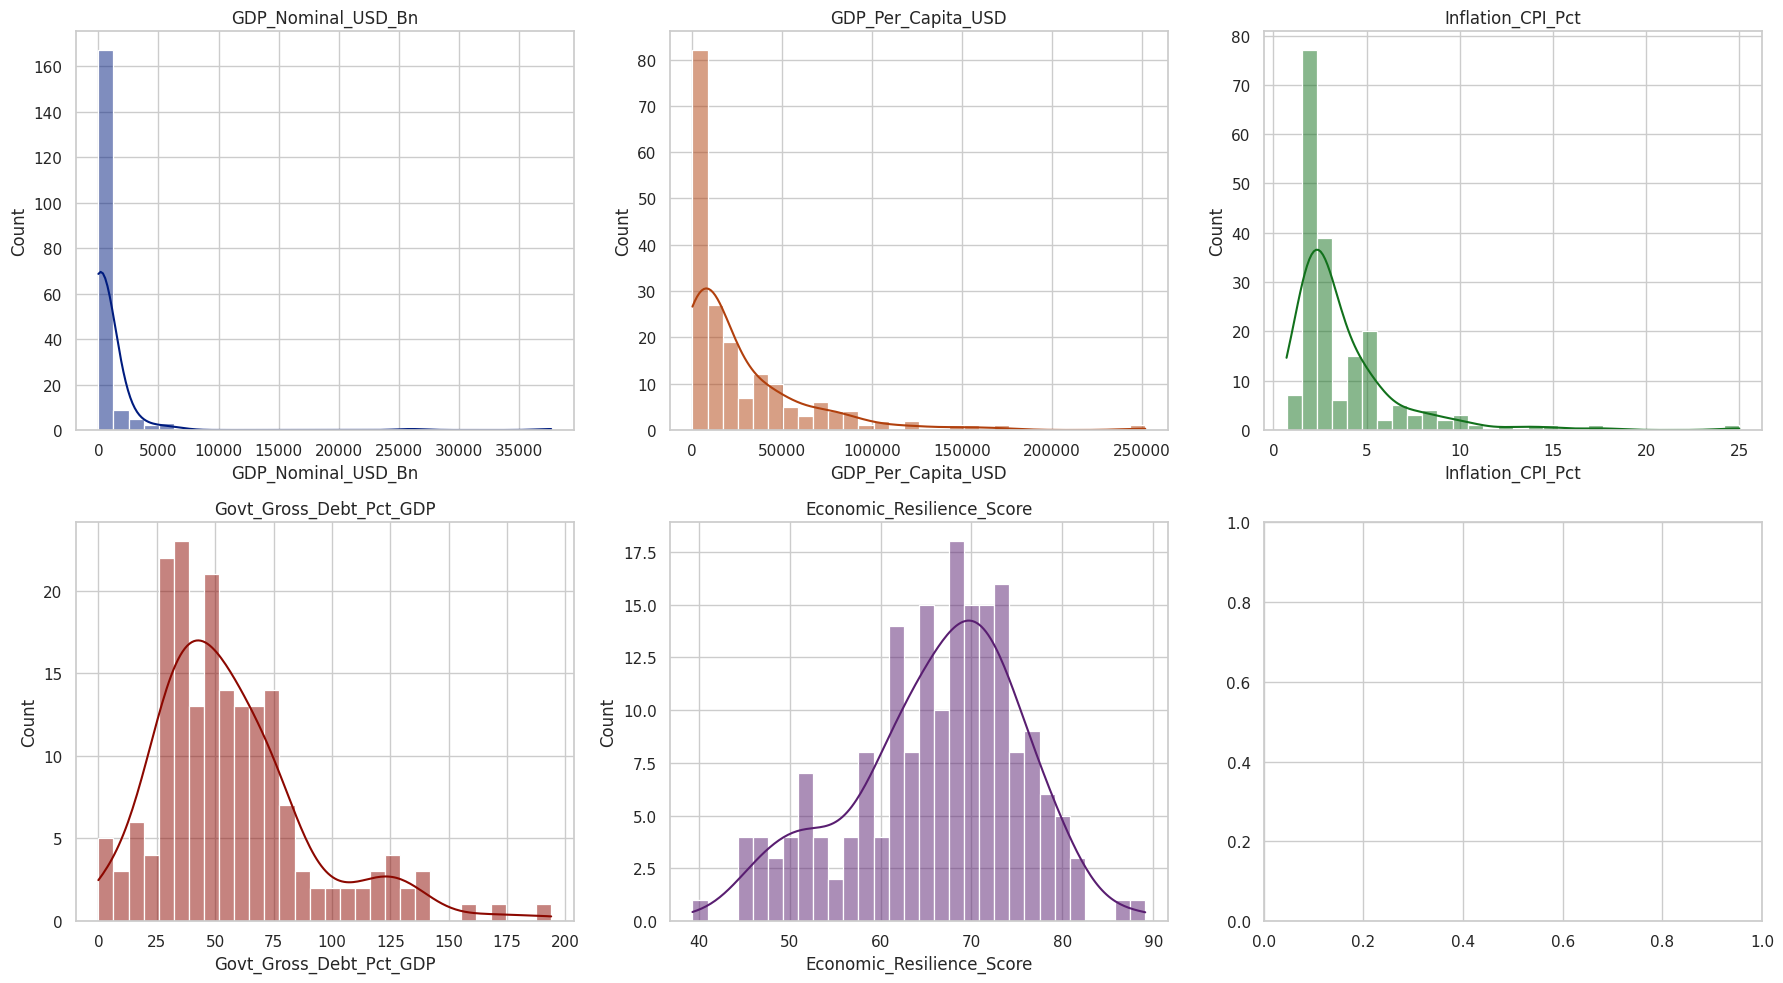

In [6]:

latest = df_country[df_country["year"] == df_country["year"].max()]

metrics = [
    "GDP_Nominal_USD_Bn",
    "GDP_Per_Capita_USD",
    "Inflation_CPI_Pct",
    "Govt_Gross_Debt_Pct_GDP",
    "Economic_Resilience_Score"
]

fig, axes = plt.subplots(2,3, figsize=(18,10))

axes = axes.flatten()

for i,col in enumerate(metrics):
    sns.histplot(latest[col].dropna(),
                 bins=30,
                 kde=True,
                 ax=axes[i],
                 color=sns.color_palette("dark",5)[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


### Observations

- The distributions highlight the extreme heterogeneity of the global economy. GDP-related variables are heavily right-skewed, reflecting the concentration of economic output among a small number of large economies. Inflation, debt, and resilience measures display much broader variation, suggesting substantial differences in macroeconomic conditions across countries.

- The resilience metric appears more concentrated than GDP, indicating that economic resilience is not determined solely by economic size.

## Top Economies by Nominal GDP

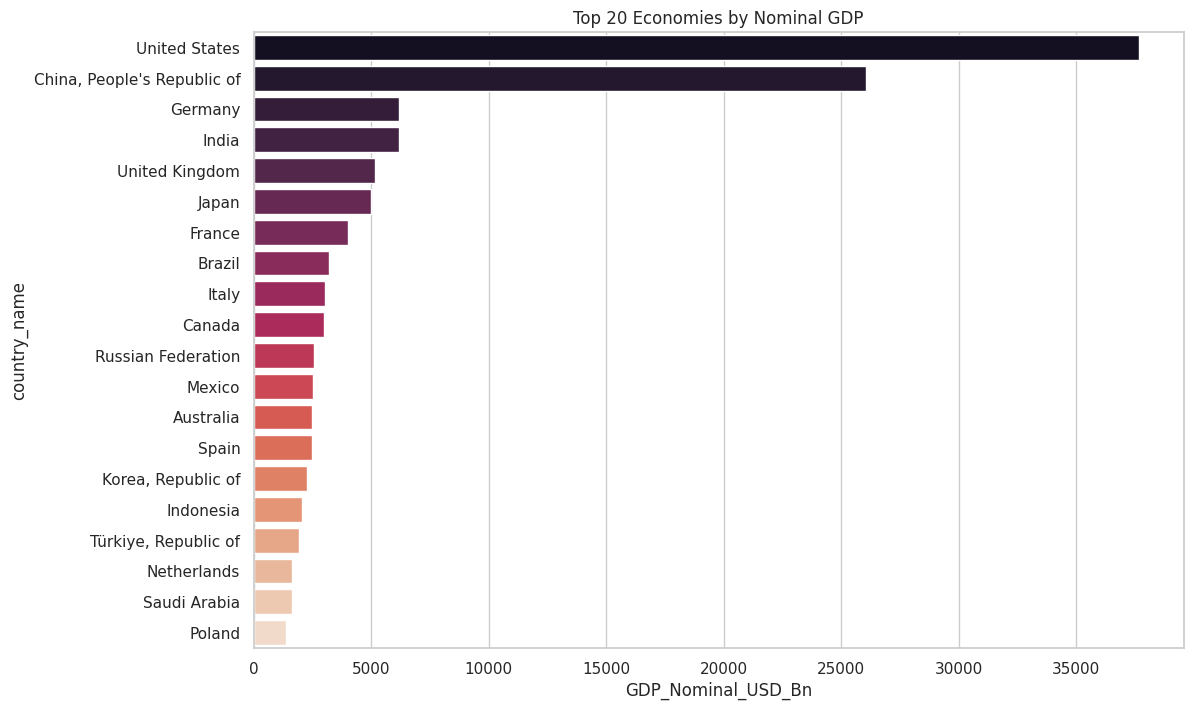

In [7]:

top_gdp = (
    latest
    .sort_values("GDP_Nominal_USD_Bn", ascending=False)
    .head(20)
)

plt.figure(figsize=(12,8))
sns.barplot(
    data=top_gdp,
    y="country_name",
    x="GDP_Nominal_USD_Bn",
    palette="rocket"
)
plt.title("Top 20 Economies by Nominal GDP")
plt.show()


### Observations

- Nominal GDP remains concentrated among a relatively small group of economies. The gap between the largest economies and the rest of the world is substantial, illustrating the unequal distribution of global economic activity.

- Even though many economies contribute meaningfully to regional growth, a handful of countries continue to dominate total global output.

## Inflation Landscape

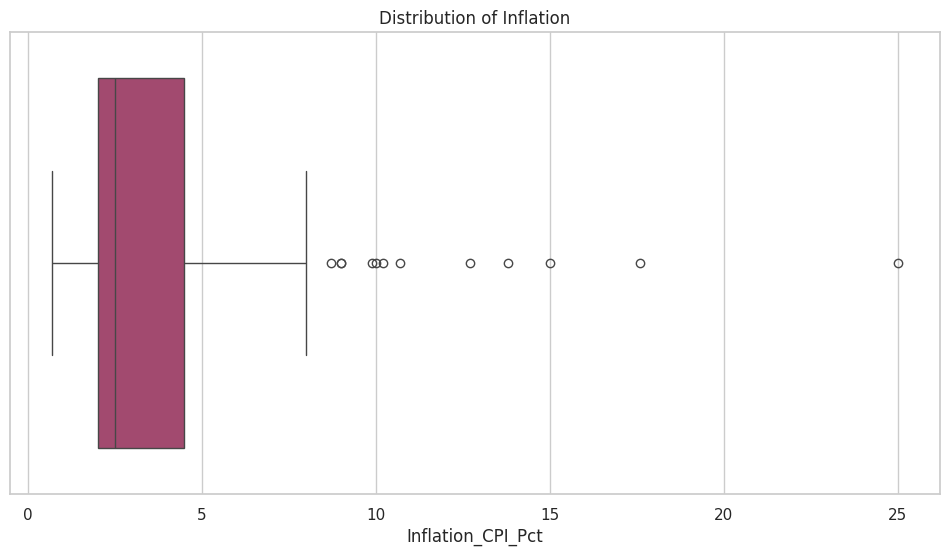

In [8]:

plt.figure(figsize=(12,6))
sns.boxplot(
    x=latest["Inflation_CPI_Pct"],
    color=sns.color_palette("flare")[3]
)
plt.title("Distribution of Inflation")
plt.show()


### Observations

- The inflation distribution reveals that most countries operate within a moderate inflation range, while a smaller group experiences significantly higher inflation rates. These outliers have a strong influence on global averages and demonstrate how inflation challenges remain unevenly distributed across regions.

- This pattern also suggests that median inflation is likely a more informative summary statistic than the mean.

## Economic Resilience Rankings

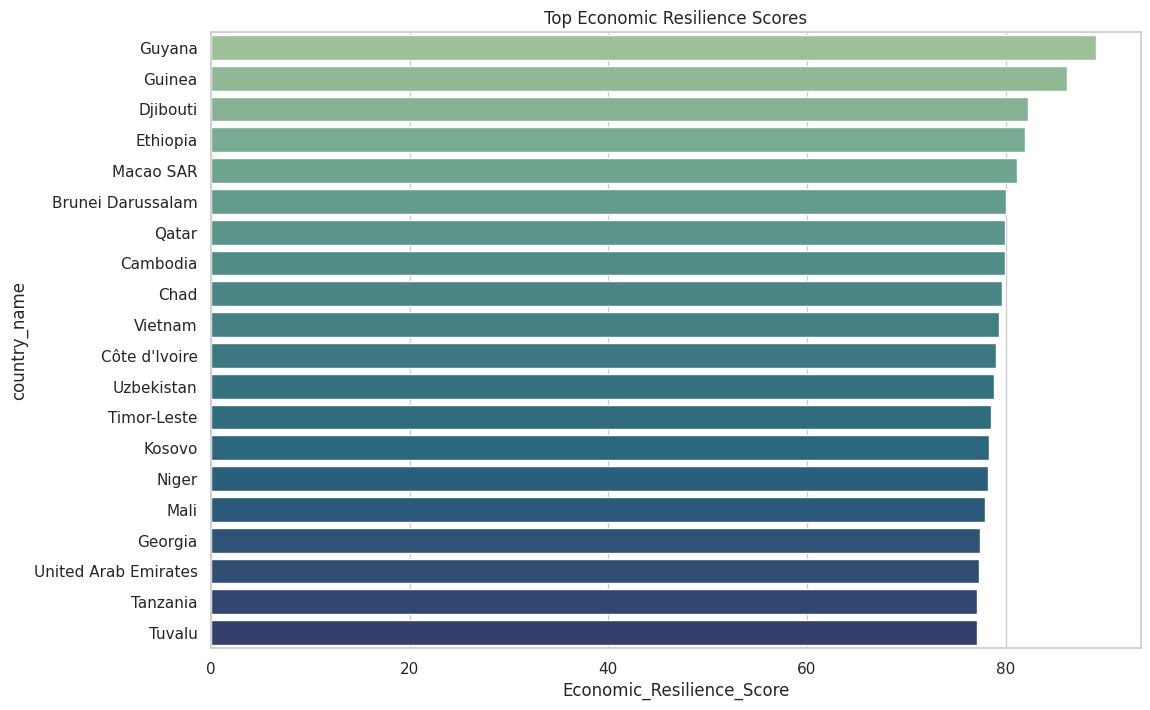

In [9]:

res = latest.sort_values("Economic_Resilience_Score", ascending=False).head(20)

plt.figure(figsize=(12,8))
sns.barplot(
    data=res,
    y="country_name",
    x="Economic_Resilience_Score",
    palette="crest"
)
plt.title("Top Economic Resilience Scores")
plt.show()


### Observations

- The highest-ranked economies combine several favorable characteristics: stable inflation, sustainable debt levels, and relatively strong growth performance. High resilience scores are not restricted to the largest economies, indicating that policy stability and macroeconomic balance are as important as economic scale.

- The ranking provides a useful benchmark for identifying countries that appear better positioned to absorb future economic shocks.

## Correlation Structure

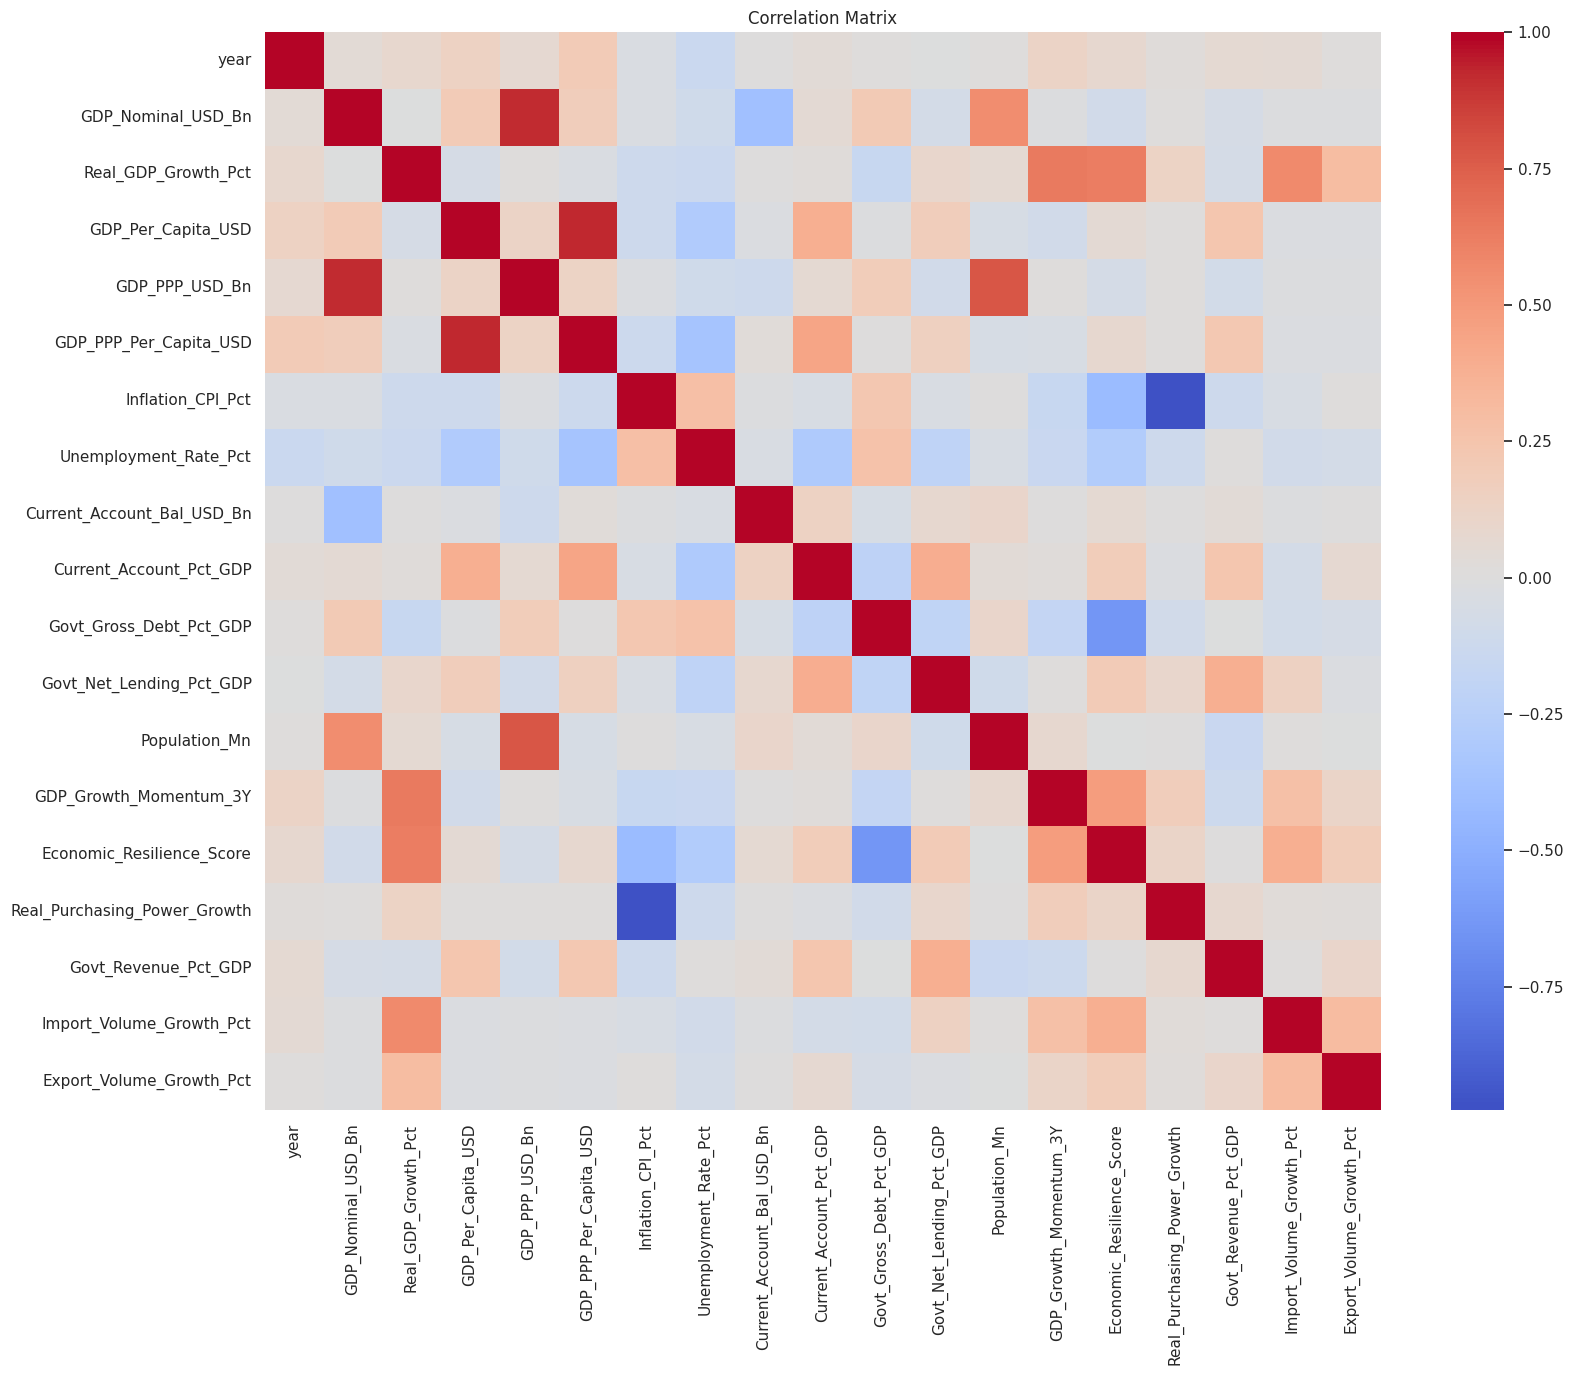

In [10]:

corr = df_country[numeric_cols].corr()

plt.figure(figsize=(18,14))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.show()


### Observations

- The correlation matrix highlights several intuitive relationships. Measures of economic size tend to move together, while debt, inflation, and growth often display more complex interactions. Strong correlations between related GDP indicators validate the internal consistency of the dataset.

- At the same time, the absence of extremely strong correlations across many policy variables suggests that macroeconomic outcomes are influenced by multiple factors rather than any single indicator.

## Top vs Bottom Resilience comparison

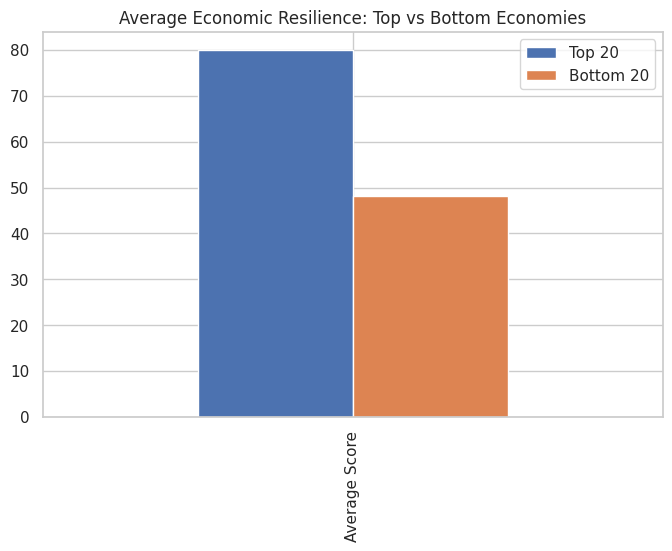

In [11]:
top20 = latest.nlargest(
    20,
    "Economic_Resilience_Score"
)

bottom20 = latest.nsmallest(
    20,
    "Economic_Resilience_Score"
)

comparison = pd.DataFrame({
    "Top 20": top20[
        "Economic_Resilience_Score"
    ].mean(),
    "Bottom 20": bottom20[
        "Economic_Resilience_Score"
    ].mean()
}, index=["Average Score"])

comparison.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Average Economic Resilience: Top vs Bottom Economies"
)
plt.show()

### Observations
- The gap between the top and bottom resilience groups exceeds 30 points, highlighting large differences in macroeconomic stability across countries.
- Economies in the top resilience group tend to combine stronger growth fundamentals with lower inflationary pressures and more sustainable debt levels.
- Lower-ranked economies face a less favorable macroeconomic environment, reflected in significantly weaker resilience scores.
- The wide separation between the two groups suggests that resilience remains a key differentiator in long-term economic performance and stability.

## GDP Growth versus Inflation

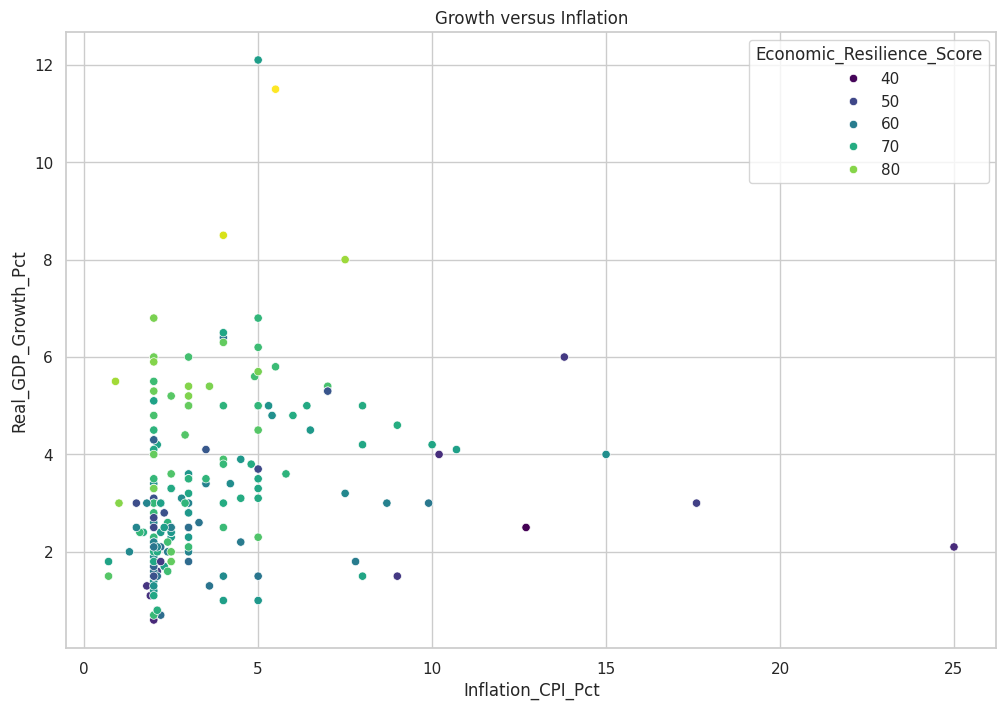

In [12]:

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=latest,
    x="Inflation_CPI_Pct",
    y="Real_GDP_Growth_Pct",
    hue="Economic_Resilience_Score",
    palette="viridis",
    alpha=1
)

plt.title("Growth versus Inflation")
plt.show()


### Observations

- The relationship between growth and inflation is not purely linear. Many economies achieve moderate growth with moderate inflation, while others experience elevated inflation without corresponding growth gains.

- The color gradient associated with resilience suggests that countries with stronger resilience scores are often located in regions characterized by healthier growth-inflation tradeoffs.

## Forecast versus Historical Comparison

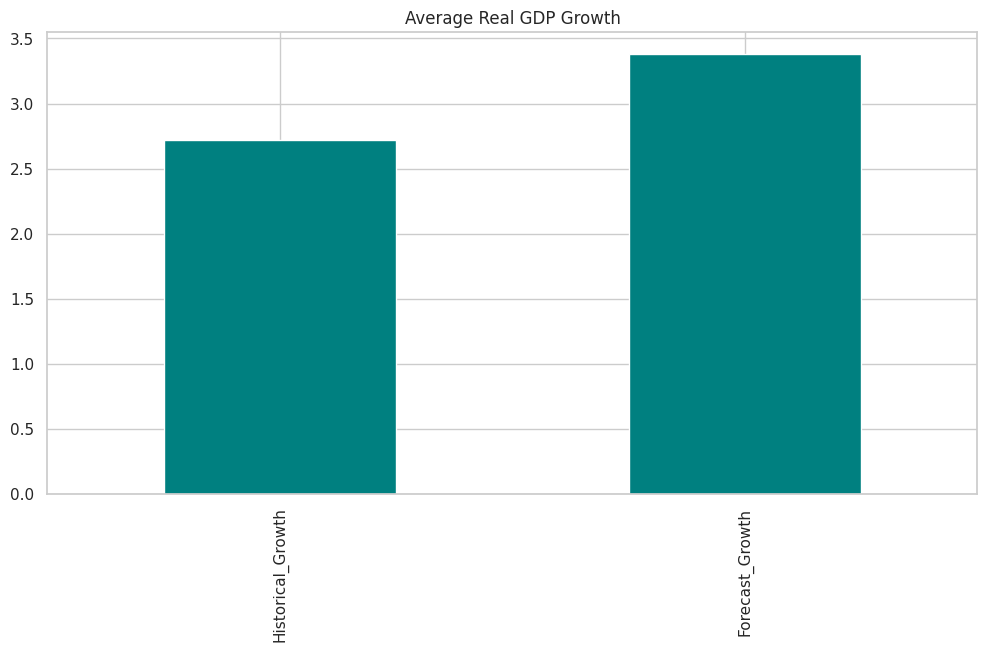

In [13]:

hist = df_country[df_country["is_forecast"]==False]
fcst = df_country[df_country["is_forecast"]==True]

comparison = pd.DataFrame({
    "Historical_Growth":[hist["Real_GDP_Growth_Pct"].mean()],
    "Forecast_Growth":[fcst["Real_GDP_Growth_Pct"].mean()]
})

comparison.T.plot(kind="bar", legend=False, color="teal")
plt.title("Average Real GDP Growth")
plt.show()


### Observations

- Average forecast growth remains positive relative to the historical sample, indicating that IMF projections generally anticipate continued global expansion through 2030. The difference between historical and forecast averages is informative because it captures the IMF's aggregate assessment of future economic conditions.

- Forecast values should nevertheless be interpreted as scenarios rather than certainties, particularly for economies facing geopolitical or fiscal risks.

## Country Clustering

In [14]:

cluster_features = [
    "GDP_Per_Capita_USD",
    "Inflation_CPI_Pct",
    "Govt_Gross_Debt_Pct_GDP",
    "Current_Account_Pct_GDP",
    "Economic_Resilience_Score"
]

cluster_df = latest[cluster_features].copy()

imp = SimpleImputer(strategy="median")
X = imp.fit_transform(cluster_df)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)

clusters = kmeans.fit_predict(X_scaled)

latest["cluster"] = clusters

latest["cluster"].value_counts()


cluster
2    72
1    62
4    21
3    21
0    13
Name: count, dtype: int64

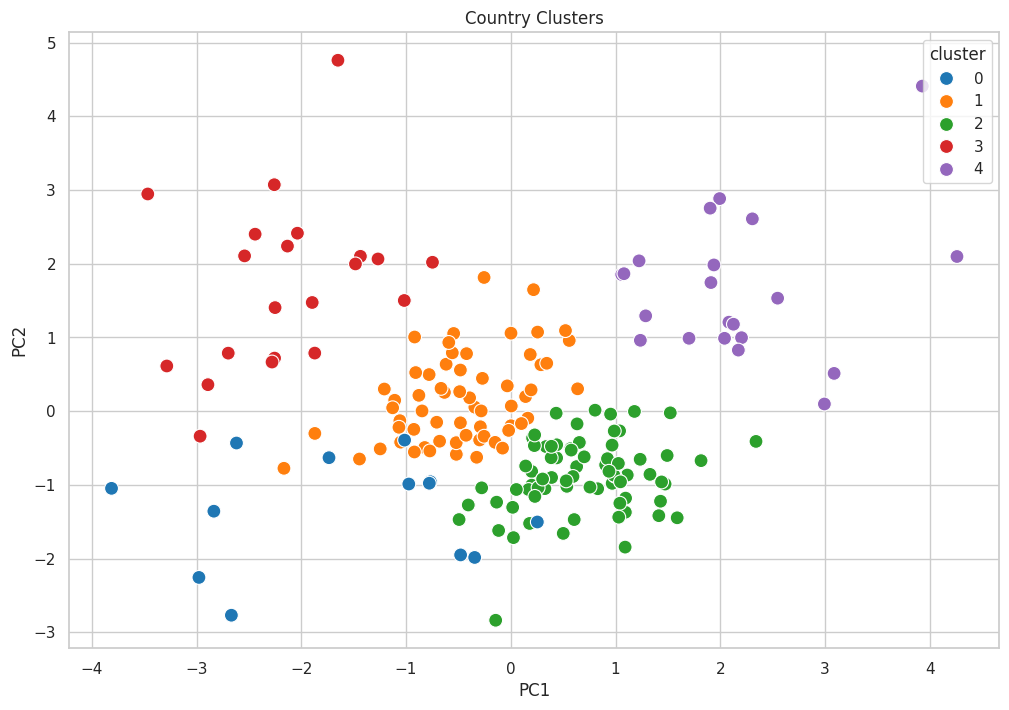

In [15]:

pca = PCA(n_components=2, random_state=42)

pca_data = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PC1": pca_data[:,0],
    "PC2": pca_data[:,1],
    "cluster": latest["cluster"]
})

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=100
)

plt.title("Country Clusters")
plt.show()


### Observations

- The clustering exercise identifies distinct economic groups rather than a single continuum of development. Countries with similar income levels, debt burdens, inflation environments, and resilience profiles tend to be positioned close together in the reduced feature space.

- This result suggests that meaningful economic archetypes exist across the global economy and that countries can often be compared most effectively against peers within the same cluster.

## Economic Profile of Country Clusters

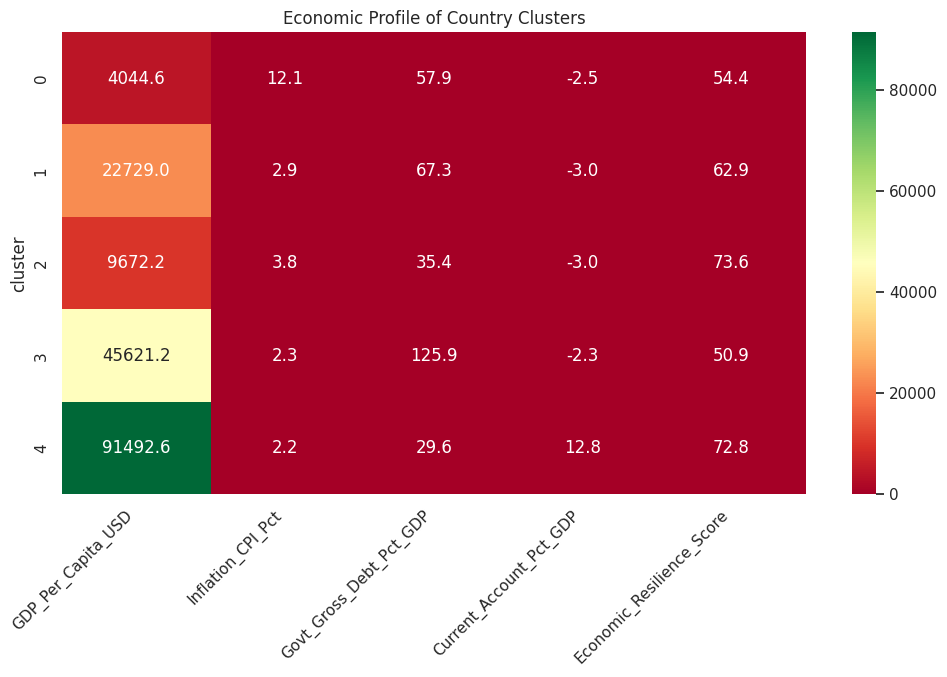

In [16]:
cluster_profile = (
    latest.groupby("cluster")[
        [
            "GDP_Per_Capita_USD",
            "Inflation_CPI_Pct",
            "Govt_Gross_Debt_Pct_GDP",
            "Current_Account_Pct_GDP",
            "Economic_Resilience_Score"
        ]
    ]
    .mean()
)

plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn"
)

plt.title("Economic Profile of Country Clusters")
plt.xticks(rotation=45, ha="right")
plt.show()

### Observations
- Cluster 4 represents the strongest economic profile, combining very high GDP per capita, low inflation, positive current account balances, and high resilience scores.
- Cluster 2 achieves the highest average resilience score despite having a lower income level than the wealthiest clusters, suggesting a balanced mix of growth, inflation stability, and debt sustainability.
- Cluster 3 consists of high-income economies with substantially higher government debt burdens, which contributes to a lower resilience score relative to other developed clusters.
- Cluster 0 exhibits the weakest overall profile, characterized by lower income levels, higher inflation, and below-average resilience outcomes.

## Machine Learning: Predict Economic Resilience

In [17]:
print("Missing values in target:")
print(df_country["Economic_Resilience_Score"].isna().sum())

print("\nMissing percentage:")
print(
    round(
        df_country["Economic_Resilience_Score"].isna().mean() * 100,
        2
    ),
    "%"
)

Missing values in target:
1

Missing percentage:
0.03 %


In [18]:
target = "Economic_Resilience_Score"

features = [
    "GDP_Nominal_USD_Bn",
    "Real_GDP_Growth_Pct",
    "GDP_Per_Capita_USD",
    "Inflation_CPI_Pct",
    "Govt_Gross_Debt_Pct_GDP",
    "Current_Account_Pct_GDP",
    "Population_Mn"
]

ml = df_country[features + [target]].copy()

ml = ml.dropna(subset=[target])

X = ml[features]
y = ml[target]

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print(f"Training Rows : {len(X_train):,}")
print(f"Testing Rows  : {len(X_test):,}")
print(f"R² Score      : {r2_score(y_test, preds):.4f}")
print(f"MAE           : {mean_absolute_error(y_test, preds):.4f}")

Training Rows : 2,320
Testing Rows  : 580
R² Score      : 0.9783
MAE           : 1.1641


### Observations

- The model achieves a very high coefficient of determination, indicating that the selected macroeconomic indicators explain a large proportion of the variation in the resilience score.

- This outcome is expected because the resilience metric itself is partially derived from macroeconomic fundamentals such as growth, inflation, and debt sustainability. Therefore, the model should be viewed primarily as a validation exercise rather than a purely predictive forecasting system.

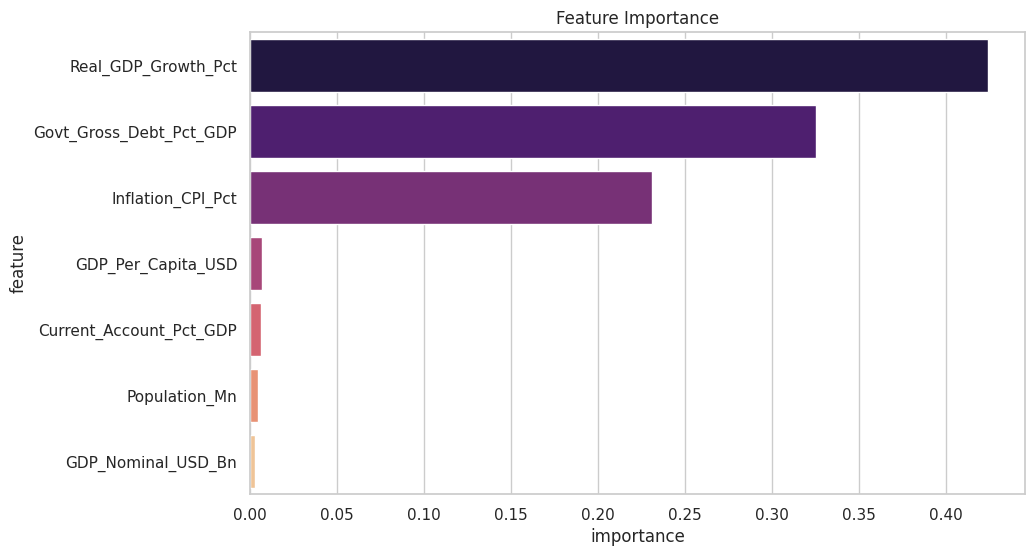

,feature,importance
1,Real_GDP_Growth_Pct,0.424237
4,Govt_Gross_Debt_Pct_GDP,0.325100
3,Inflation_CPI_Pct,0.230824
2,GDP_Per_Capita_USD,0.006874
5,Current_Account_Pct_GDP,0.005878
6,Population_Mn,0.004270
0,GDP_Nominal_USD_Bn,0.002818


In [19]:

importance = pd.DataFrame({
    "feature":features,
    "importance":model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    y="feature",
    x="importance",
    palette="magma"
)

plt.title("Feature Importance")
plt.show()

importance


### Observations

- Feature importance analysis identifies the variables that contribute most strongly to resilience estimation. Indicators related to growth performance, inflation conditions, and fiscal sustainability are expected to dominate because they are closely connected to the construction of the resilience framework.

- The ranking also provides a practical roadmap for policymakers and analysts seeking to understand which macroeconomic levers are most associated with resilient economic outcomes.


## Conclusions

This notebook established a complete analytical workflow for the IMF World Economic Outlook April 2026 dataset. The analysis explored economic scale, growth, inflation, debt dynamics, resilience, forecast trends, clustering structures, and predictive modelling. The resulting framework can be extended into country intelligence dashboards, macroeconomic monitoring systems, sovereign risk analytics, and global forecasting studies.
